# EX.03

# 3-1

In [1]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
print(cv.__version__)

4.13.0


--2026-04-05 14:07:18--  https://www.dropbox.com/scl/fi/s9yuo7vbbesh0xovbohvp/left01.jpg?rlkey=7qjuuo49li287jsbhsolz2yra
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc225a16997311936f55b752504f.dl.dropboxusercontent.com/cd/0/inline/C-Cy2CyWoXAV2-ZJ3bvvIQRNNYqktX4N7z6YpO8KNXKRXxpGCjHNe77S3Ll8VS4tALek7dTi-ACtY1kq86Bzi2K8qzbJeITNLD-C3LRMri5DI8otjNeTlLNfEd6cZp5jkjLnua8HZJ7bpIj03Eof5Oep/file# [following]
--2026-04-05 14:07:18--  https://uc225a16997311936f55b752504f.dl.dropboxusercontent.com/cd/0/inline/C-Cy2CyWoXAV2-ZJ3bvvIQRNNYqktX4N7z6YpO8KNXKRXxpGCjHNe77S3Ll8VS4tALek7dTi-ACtY1kq86Bzi2K8qzbJeITNLD-C3LRMri5DI8otjNeTlLNfEd6cZp5jkjLnua8HZJ7bpIj03Eof5Oep/file
Resolving uc225a16997311936f55b752504f.dl.dropboxusercontent.com (uc225a16997311936f55b752504f.dl.dropboxusercontent.com)... 162.125.1.15, 2620:100

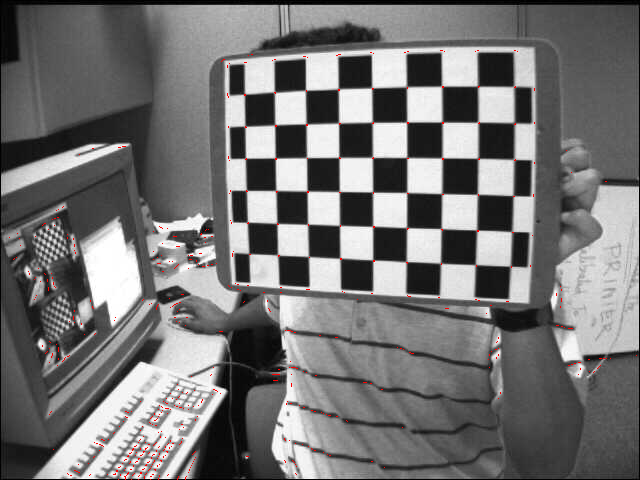

In [2]:
# Harris corner
!wget --content-disposition https://www.dropbox.com/scl/fi/s9yuo7vbbesh0xovbohvp/left01.jpg?rlkey=7qjuuo49li287jsbhsolz2yra&dl=0
img = cv.imread("left01.jpg")
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
# cv.cornerHarris(입력 이미지, block size, kernel size, Harris Corner 판별식 계수)
dst = cv.cornerHarris(gray, 2, 25, 0.15)
img[dst > 0.01 * dst.max()] = [0, 0, 255]
cv2_imshow(img)


# 3-2

In [3]:
!wget --content-disposition https://www.dropbox.com/scl/fi/kjp0ngrrpz2hf1ggen6e6/baboon.jpg?rlkey=k1jm8dp2eipmdjdvsowot1i4k&dl=0

--2026-04-05 14:07:30--  https://www.dropbox.com/scl/fi/kjp0ngrrpz2hf1ggen6e6/baboon.jpg?rlkey=k1jm8dp2eipmdjdvsowot1i4k
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc0c57d63b4fb0d26166fd202233.dl.dropboxusercontent.com/cd/0/inline/C-DIrU-Fzb3TFp3fHq-Xt-P-iNtkeJPSrJcdUKrL_J-iFRwlQQaowVHMNCumbsYyzJO-W1bJlow0DYGJmAavHN6IU8_-i-VaPSvxdiytLqK1MS43gJq1pLA3iF_eciwolps2vOhrYMJt5qXqNm2-glLQ/file# [following]
--2026-04-05 14:07:30--  https://uc0c57d63b4fb0d26166fd202233.dl.dropboxusercontent.com/cd/0/inline/C-DIrU-Fzb3TFp3fHq-Xt-P-iNtkeJPSrJcdUKrL_J-iFRwlQQaowVHMNCumbsYyzJO-W1bJlow0DYGJmAavHN6IU8_-i-VaPSvxdiytLqK1MS43gJq1pLA3iF_eciwolps2vOhrYMJt5qXqNm2-glLQ/file
Resolving uc0c57d63b4fb0d26166fd202233.dl.dropboxusercontent.com (uc0c57d63b4fb0d26166fd202233.dl.dropboxusercontent.com)... 162.125.1.15, 2620:100

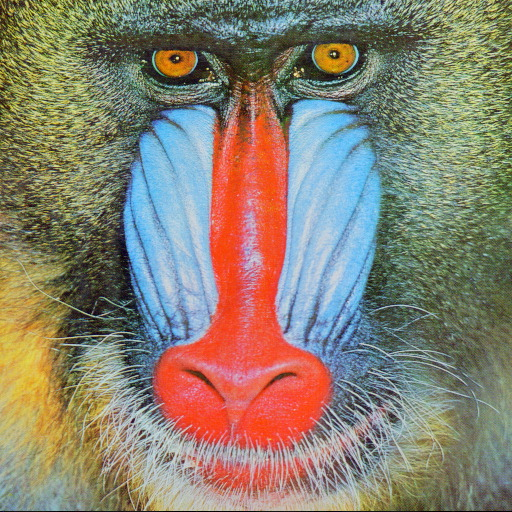

In [4]:
img = cv.imread("baboon.jpg")
cv2_imshow(img)

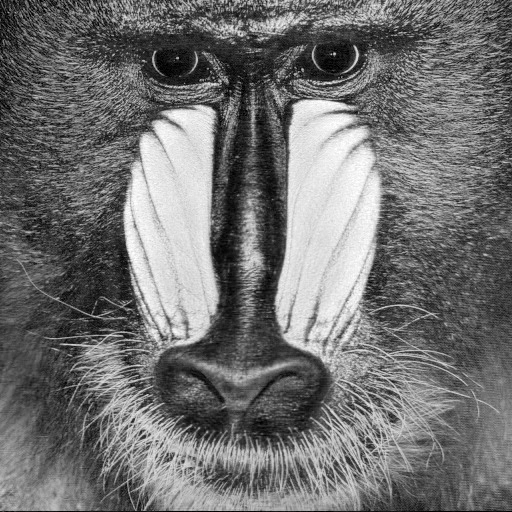

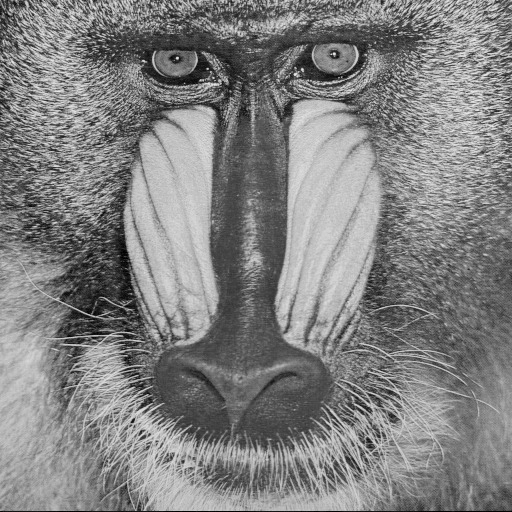

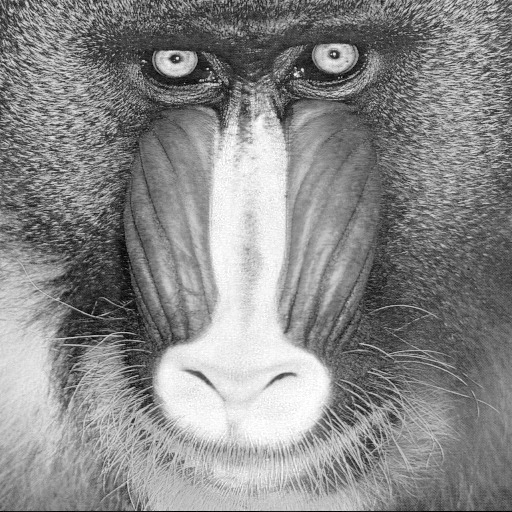

In [8]:
# 각 채널의 명암을 확인하기 위한 채널 분리
(B, G, R) = cv.split(img)
cv2_imshow(B)
cv2_imshow(G)
cv2_imshow(R)

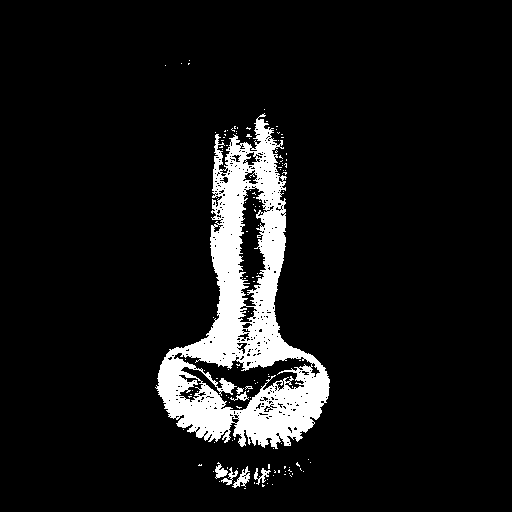

In [9]:
ext = cv.inRange(img, (0, 0, 200), (100, 100, 255)) # segmentation
cv2_imshow(ext)

In [10]:
# histogram (functions)
def hist_lines(inp):
    bins = np.zeros((256*3,2), np.int32 )
    bins[:,0:1] = np.arange(256*3).reshape(256*3, 1)
    color = [ (255,0,0),(0,255,0),(0,0,255) ]
    out = np.zeros((300,256*3,3))
    for ch, col in enumerate(color):
        hist_item = cv.calcHist([inp],[ch],None,[256],[0,256])
        cv.normalize(hist_item,hist_item,0,255,cv.NORM_MINMAX)
        hist=np.int32(np.around(hist_item))
        bins[256*ch:256*(ch+1),1:2] = hist
        for x, y in zip(bins[256*ch:256*(ch+1),0:1], hist):
            x, y = int(x), int(y)
            cv.line(out,(x,0),(x,y),col)
    out = np.flipud(out)
    return out

/tmp/ipykernel_42000/1271564290.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x, y = int(x), int(y)


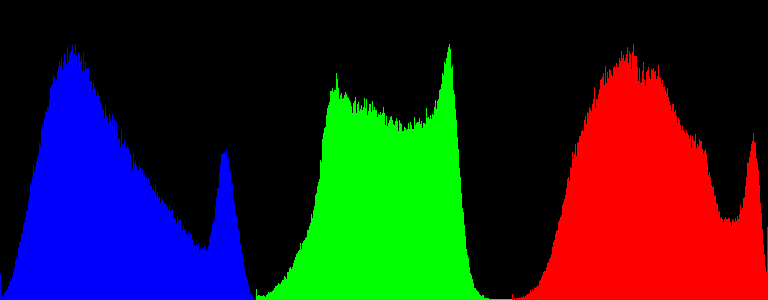

In [11]:
# histogram (visualization)
lines = hist_lines(img)
cv2_imshow(lines)

/tmp/ipykernel_42000/1271564290.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  x, y = int(x), int(y)


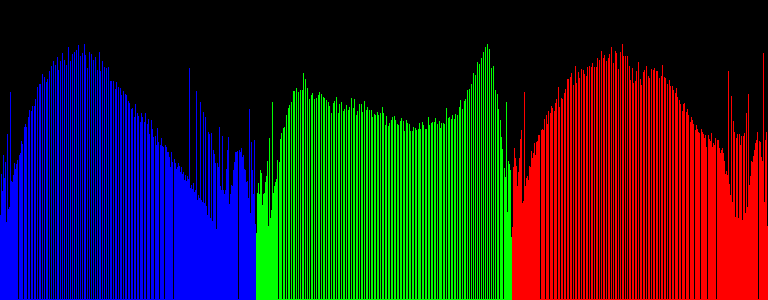

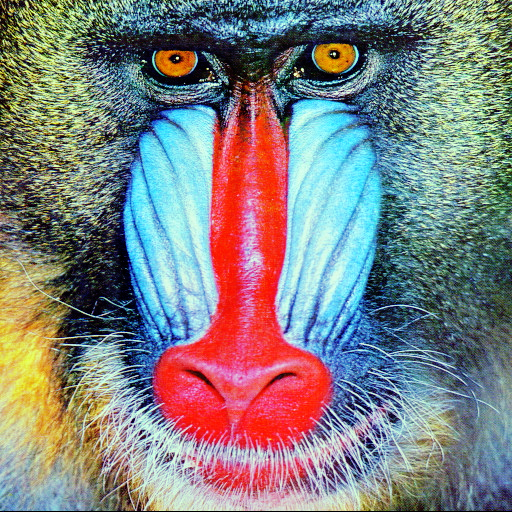

In [13]:
# equalization
R_eq = cv.equalizeHist( R )
G_eq = cv.equalizeHist( G )
B_eq = cv.equalizeHist( B )
img_eq = cv.merge([B_eq, G_eq, R_eq])
# curve_eq = hist_curve(img_eq)
lines_eq = hist_lines(img_eq)
cv2_imshow(lines_eq)
cv2_imshow(img_eq)

# 3-3

In [14]:
!wget --content-disposition https://www.dropbox.com/scl/fi/ml4hcb16r8313z0qnltj8/box.png?rlkey=6kcv6ewogslkdsl0xosucksz4&dl=0
!wget --content-disposition https://www.dropbox.com/scl/fi/1laospri2bm4gfsucuw9h/box_in_scene.png?rlkey=rir9h7ch73dygxhk81knjw5ox&dl=0

--2026-04-05 14:36:05--  https://www.dropbox.com/scl/fi/ml4hcb16r8313z0qnltj8/box.png?rlkey=6kcv6ewogslkdsl0xosucksz4
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucd1ed4a58247e2af6e2dc8ee0e9.dl.dropboxusercontent.com/cd/0/inline/C-CdsMZrtdxaO_HOLVnIgmiClVSXAoLcCQhUNcolZUcQzNiAqI6X-idAWPuPAQxIy8NM6xE7x8PRp8ewdAW6Y3Ld40OblA-XZYLZCgCouinNJSz7-eGILCKLvJ35y7GQjROfBuW38Kc1ko9CFxY-HNTG/file# [following]
--2026-04-05 14:36:06--  https://ucd1ed4a58247e2af6e2dc8ee0e9.dl.dropboxusercontent.com/cd/0/inline/C-CdsMZrtdxaO_HOLVnIgmiClVSXAoLcCQhUNcolZUcQzNiAqI6X-idAWPuPAQxIy8NM6xE7x8PRp8ewdAW6Y3Ld40OblA-XZYLZCgCouinNJSz7-eGILCKLvJ35y7GQjROfBuW38Kc1ko9CFxY-HNTG/file
Resolving ucd1ed4a58247e2af6e2dc8ee0e9.dl.dropboxusercontent.com (ucd1ed4a58247e2af6e2dc8ee0e9.dl.dropboxusercontent.com)... 162.125.1.15, 2620:100:60

In [15]:
# Load the images.
img0 = cv.imread("box.png", cv.IMREAD_GRAYSCALE)
img1 = cv.imread("box_in_scene.png", 0)

In [23]:
# Perform SIFT/ORB feature detection and description.
sift = cv.SIFT_create()
kp0, des0 = sift.detectAndCompute(img0, None) # 특징점 검출 & 특징 기술
kp1, des1 = sift.detectAndCompute(img1, None)
#orb = cv.ORB_create()
#kp0, des0 = orb.detectAndCompute(img0, None)
#kp1, des1 = orb.detectAndCompute(img1, None)

In [17]:
# Perform brute-force KNN matching.
bf = cv.BFMatcher(cv.DescriptorMatcher_BRUTEFORCE, crossCheck=False)
pairs_of_matches = bf.knnMatch(des0, des1, k=2)

In [18]:
# Sort the pairs of matches by distance.
# Draw the 20 best pairs of matches.
pairs_of_matches = sorted(pairs_of_matches, key=lambda x:x[0].distance)
img_pairs_of_matches = cv.drawMatchesKnn( img0, kp0, img1, kp1, pairs_of_matches[:20], img1, flags=cv.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)

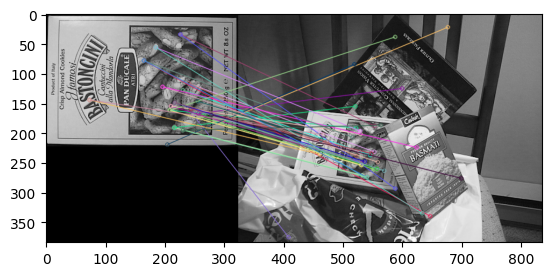

In [24]:
# Show the pairs of matches.
plt.imshow(img_pairs_of_matches)
plt.show()

In [25]:
# Apply the ratio test.
matches = [x[0] for x in pairs_of_matches if len(x) > 1 and x[0].distance < 0.8 * x[1].distance]

In [21]:
# Draw the best 20 matches.
img_matches = cv.drawMatches( img0, kp0, img1, kp1, matches[:20], img1, flags=cv.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)

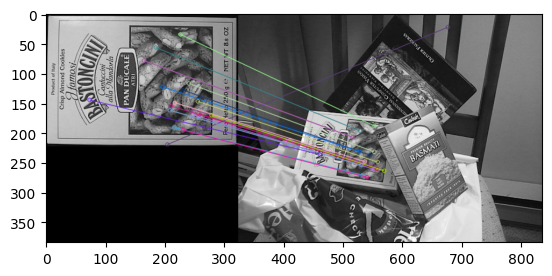

In [26]:
# Show the matches.
plt.imshow(img_matches)
plt.show()